In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore


In [2]:
df = pd.read_csv("data/sudan.csv")

if not {"YEAR", "DOY"}.issubset(df.columns):
    # NASA files may include metadata lines before the actual header.
    df = pd.read_csv("data/sudan.csv", skiprows=14)

required_cols = {"YEAR", "DOY"}
if not required_cols.issubset(df.columns):
    raise ValueError(f"Missing required columns after load: {required_cols - set(df.columns)}")

df["Country"] = "Sudan"
print(f"Loaded sudan.csv with shape {df.shape}")

Loaded sudan.csv with shape (4108, 13)


In [3]:
df["date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["date"].dt.month

In [4]:
df.replace(-999, np.nan, inplace=True)

dup_count = df.duplicated().sum()
print("Duplicate rows (all columns):", dup_count)

if {"YEAR", "DOY"}.issubset(df.columns):
    dup_year_doy = df.duplicated(subset=["YEAR", "DOY"], keep=False).sum()
    print("Rows sharing YEAR+DOY keys:", dup_year_doy)

df = df.drop_duplicates()
print("Rows after deduplication:", len(df))

Duplicate rows (all columns): 0
Rows sharing YEAR+DOY keys: 0
Rows after deduplication: 4108


In [5]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
summary_stats = df[numeric_cols].describe().T
summary_stats

,count,mean,std,min,25%,50%,75%,max
YEAR,4108.0,2020.131451,3.248907,2015.00,2017.0000,2020.000,2023.000,2026.00
DOY,4108.0,180.121227,106.294767,1.00,86.0000,179.000,272.000,366.00
T2M,4108.0,28.759007,4.681305,13.18,25.5600,29.160,32.510,37.99
T2M_MAX,4108.0,36.773914,4.400065,21.04,33.7300,37.020,40.330,45.96
T2M_MIN,4108.0,21.508510,5.091142,5.93,17.4975,22.890,25.430,32.17
T2M_RANGE,4108.0,15.265404,3.298919,3.42,13.2800,15.810,17.680,22.48
PRECTOTCORR,4108.0,0.643875,3.057672,0.00,0.0000,0.000,0.010,66.49
RH2M,4108.0,31.359192,17.851849,4.69,17.4075,26.630,40.535,87.16
WS2M,4108.0,3.484253,1.040667,0.61,2.7300,3.490,4.220,7.15
WS2M_MAX,4108.0,5.157378,1.280238,1.03,4.2675,5.120,6.020,9.05


In [6]:
missing_count = df.isna().sum()
missing_pct = (missing_count / len(df)) * 100

print("Missing count by column:")
print(missing_count.sort_values(ascending=False))
print("\nMissing percent by column:")
print(missing_pct.sort_values(ascending=False).round(2))

high_missing = missing_pct[missing_pct > 5].sort_values(ascending=False)
if high_missing.empty:
    print("\nNo columns exceed 5% missing values.")
else:
    print("\nColumns above 5% missing:")
    print(high_missing.round(2))

Missing count by column:
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
date           0
Month          0
dtype: int64

Missing percent by column:
YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
date           0.0
Month          0.0
dtype: float64

No columns exceed 5% missing values.


In [7]:
cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]
z = np.abs(zscore(df[cols], nan_policy="omit"))
outlier_rows = (z > 3).any(axis=1)
print("Outlier rows:", outlier_rows.sum())
print("Outliers by variable:", (z > 3).sum(axis=0))

Outlier rows: 84
Outliers by variable: [ 3  6  1 71  3  4  3]


In [8]:
row_missing_pct = df.isna().mean(axis=1) * 100
rows_to_drop = row_missing_pct > 30
print("Rows dropped for >30% missing values:", rows_to_drop.sum())
df = df.loc[~rows_to_drop].copy()

df[cols] = df[cols].ffill()
print("Remaining missing values in weather columns after ffill:")
print(df[cols].isna().sum())

import os
os.makedirs("data", exist_ok=True)
df.to_csv("data/sudan_clean.csv", index=False)
print("Saved cleaned file to data/sudan_clean.csv")

Rows dropped for >30% missing values: 0
Remaining missing values in weather columns after ffill:
T2M            0
T2M_MAX        0
T2M_MIN        0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
dtype: int64
Saved cleaned file to data/sudan_clean.csv


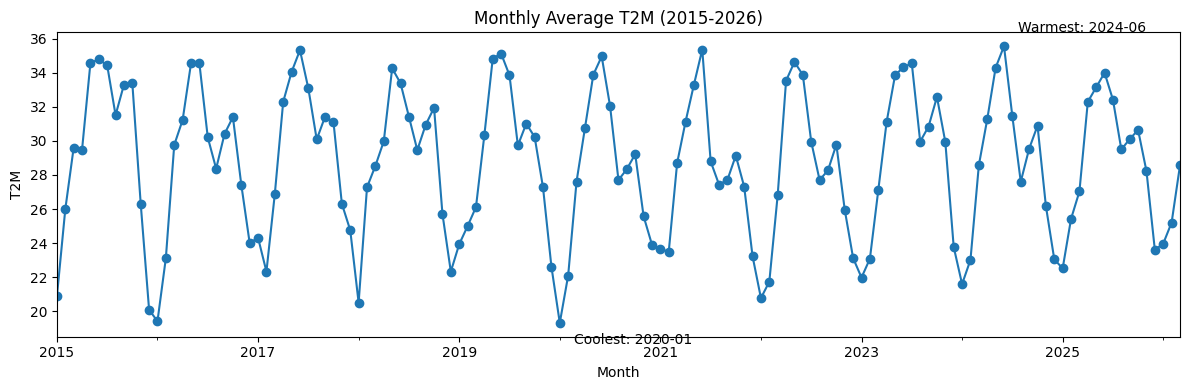

In [9]:
monthly_temp_ts = df.set_index("date").resample("MS")["T2M"].mean()
ax = monthly_temp_ts.plot(
    marker="o",
    figsize=(12, 4),
    title="Monthly Average T2M (2015-2026)"
)

warm_date = monthly_temp_ts.idxmax()
cool_date = monthly_temp_ts.idxmin()
ax.annotate(
    f"Warmest: {warm_date:%Y-%m}",
    xy=(warm_date, monthly_temp_ts.loc[warm_date]),
    xytext=(10, 10),
    textcoords="offset points"
    )
ax.annotate(
    f"Coolest: {cool_date:%Y-%m}",
    xy=(cool_date, monthly_temp_ts.loc[cool_date]),
    xytext=(10, -15),
    textcoords="offset points"
    )

plt.xlabel("Month")
plt.ylabel("T2M")
plt.tight_layout()
plt.show()

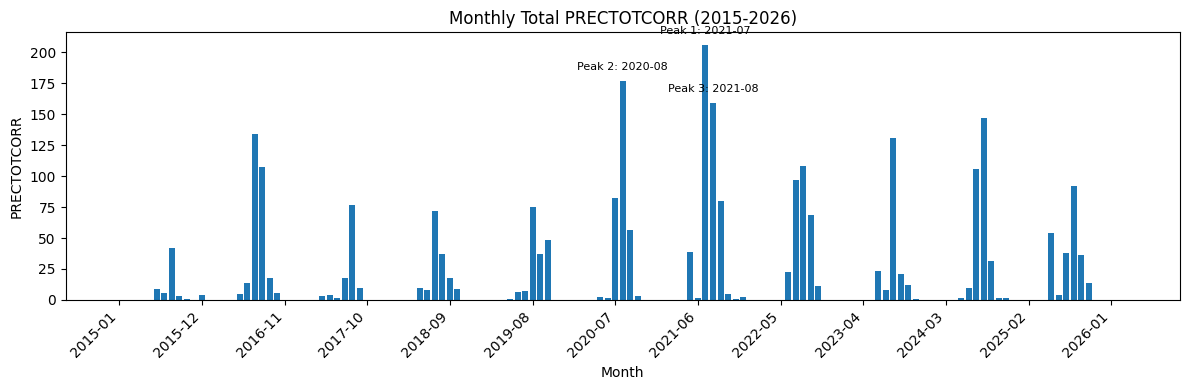

In [10]:
monthly_rain_ts = df.set_index("date").resample("MS")["PRECTOTCORR"].sum()
x = np.arange(len(monthly_rain_ts))
labels = monthly_rain_ts.index.strftime("%Y-%m")

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x, monthly_rain_ts.values)
ax.set_title("Monthly Total PRECTOTCORR (2015-2026)")

peak_months = monthly_rain_ts.nlargest(3).sort_values(ascending=False)
for i, (dt, val) in enumerate(peak_months.items(), start=1):
    idx = monthly_rain_ts.index.get_loc(dt)
    ax.annotate(
        f"Peak {i}: {dt:%Y-%m}",
        xy=(idx, val),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=8
    )

tick_step = max(1, len(x) // 12)
ax.set_xticks(x[::tick_step])
ax.set_xticklabels(labels[::tick_step], rotation=45, ha="right")
plt.xlabel("Month")
plt.ylabel("PRECTOTCORR")
plt.tight_layout()
plt.show()

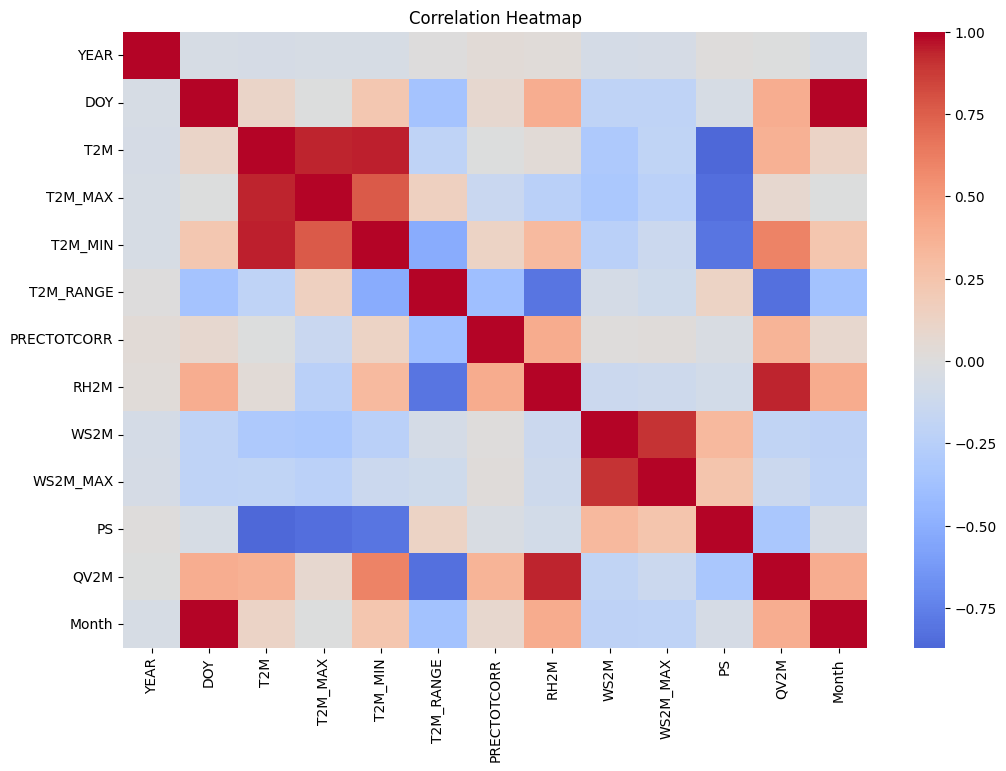

In [11]:
num_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 8))
sns.heatmap(num_df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

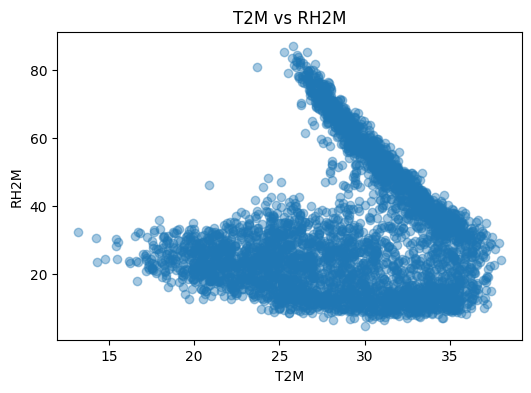

In [12]:
plt.figure(figsize=(6, 4))
plt.scatter(df["T2M"], df["RH2M"], alpha=0.4)
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.title("T2M vs RH2M")
plt.show()

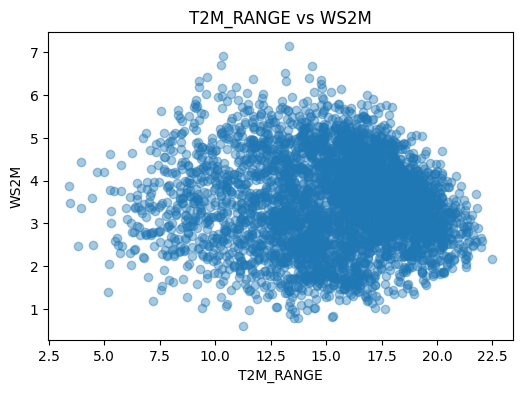

In [13]:
if "T2M_RANGE" not in df.columns:
    df["T2M_RANGE"] = df["T2M_MAX"] - df["T2M_MIN"]
plt.figure(figsize=(6, 4))
plt.scatter(df["T2M_RANGE"], df["WS2M"], alpha=0.4)
plt.xlabel("T2M_RANGE")
plt.ylabel("WS2M")
plt.title("T2M_RANGE vs WS2M")
plt.show()

In [14]:
corr_matrix = num_df.corr(numeric_only=True)
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
top_corr = upper_triangle.stack().sort_values(key=np.abs, ascending=False).head(3)

print("Top 3 strongest correlations (absolute value):")
for (var_a, var_b), corr_val in top_corr.items():
    direction = "positive" if corr_val > 0 else "negative"
    print(f"{var_a} vs {var_b}: {corr_val:.3f} ({direction})")

Top 3 strongest correlations (absolute value):
DOY vs Month: 0.997 (positive)
T2M vs T2M_MIN: 0.942 (positive)
RH2M vs QV2M: 0.935 (positive)


PRECTOTCORR skewness: 10.29
Rainfall is heavily right-skewed; inspect the log histogram below.


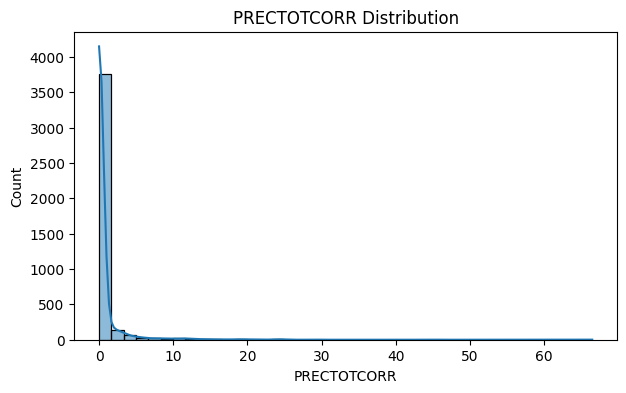

In [15]:
rain = df["PRECTOTCORR"].dropna()
rain_skew = rain.skew()
print(f"PRECTOTCORR skewness: {rain_skew:.2f}")
if rain_skew > 1:
    print("Rainfall is heavily right-skewed; inspect the log histogram below.")
elif rain_skew > 0.5:
    print("Rainfall is moderately right-skewed.")
else:
    print("Rainfall is near-symmetric or only mildly skewed.")

plt.figure(figsize=(7, 4))
sns.histplot(rain, bins=40, kde=True)
plt.title("PRECTOTCORR Distribution")
plt.show()

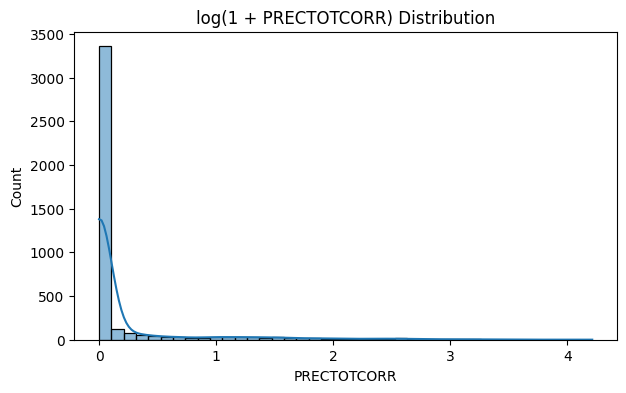

In [16]:
plt.figure(figsize=(7, 4))
sns.histplot(np.log1p(df["PRECTOTCORR"].dropna()), bins=40, kde=True)
plt.title("log(1 + PRECTOTCORR) Distribution")
plt.show()

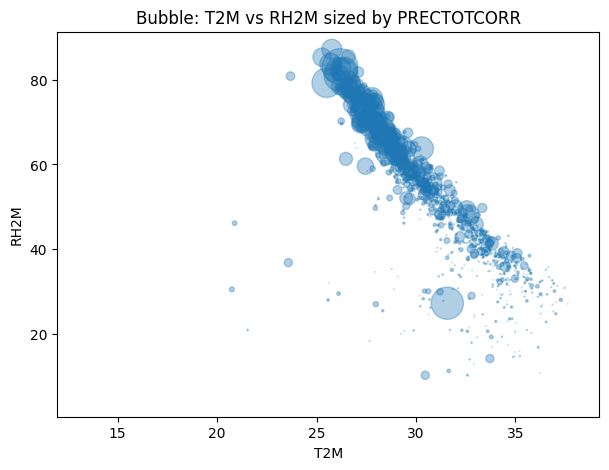

In [17]:
plt.figure(figsize=(7, 5))
size = df["PRECTOTCORR"].fillna(0).clip(lower=0) * 10
plt.scatter(df["T2M"], df["RH2M"], s=size, alpha=0.35)
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.title("Bubble: T2M vs RH2M sized by PRECTOTCORR")
plt.show()

In [18]:
df = pd.read_csv("data/sudan.csv")

if not {"YEAR", "DOY"}.issubset(df.columns):
    # Sudan CSV may include metadata lines before the actual header.
    df = pd.read_csv("data/sudan.csv", skiprows=14)

required_cols = {"YEAR", "DOY"}
if not required_cols.issubset(df.columns):
    raise ValueError(f"Missing required columns after load: {required_cols - set(df.columns)}")

df["Country"] = "Sudan"
print(f"Loaded sudan.csv with shape {df.shape}")

Loaded sudan.csv with shape (4108, 13)


## Missing values and duplicate rows
Replace NASA sentinel values before running statistics, then check for duplicates and remove them.

## Summary statistics
Numeric summary for all climate variables.

### Summary interpretation
These summary statistics describe the Ethiopia dataset and show a climate profile with meaningful spread across temperature, rainfall, and wind variables.
The temperature range is wide enough to show clear day-night variation, while the rainfall and wind metrics suggest strong seasonal differences across the record.
Overall, the values look consistent with real climate variability and do not suggest obvious data corruption.

In [19]:
missing_count = df.isna().sum()
missing_pct = (missing_count / len(df)) * 100

print("Missing count by column:")
print(missing_count.sort_values(ascending=False))
print("\nMissing percent by column:")
print(missing_pct.sort_values(ascending=False).round(2))

high_missing = missing_pct[missing_pct > 5].sort_values(ascending=False)
if high_missing.empty:
    print("\nNo columns exceed 5% missing values.")
else:
    print("\nColumns above 5% missing:")
    print(high_missing.round(2))

Missing count by column:
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
dtype: int64

Missing percent by column:
YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
dtype: float64

No columns exceed 5% missing values.


## Outlier detection
Decision: retain outlier rows by default because true climate extremes can represent real weather events, not errors. If any variable shows impossible physical values, flag and handle those records separately.

## Handle remaining missing values
Decision used in this notebook:
- Drop rows where more than 30% of columns are missing.
- Apply forward-fill to core weather variables (T2M, T2M_MAX, T2M_MIN, PRECTOTCORR, RH2M, WS2M, WS2M_MAX).
This balances data retention with quality control for downstream analysis.

## Time series analysis
Monthly temperature changes smoothly through the year, while rainfall is more irregular and concentrated in a smaller number of wetter months.
The annotations help identify the warmest and coolest months as well as the strongest rainfall peaks in the period shown.
Overall, the pattern suggests a clear seasonal cycle with rainfall spikes rather than evenly distributed precipitation.

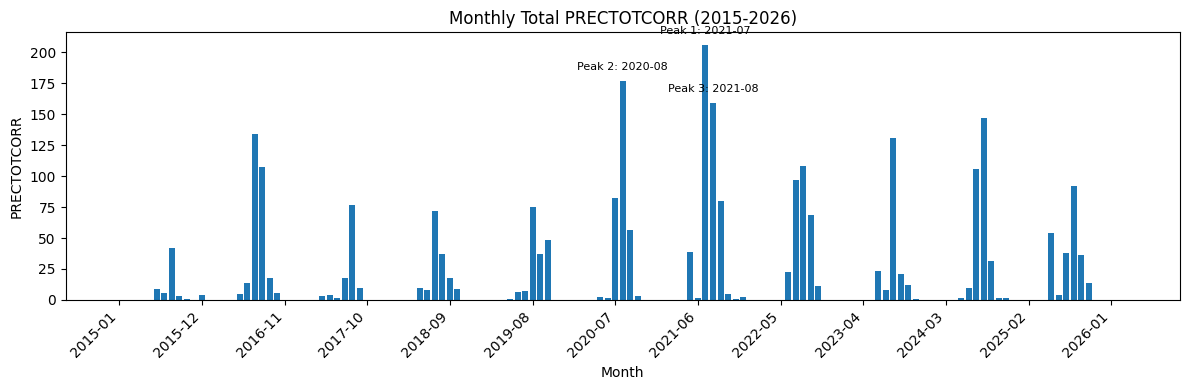

In [20]:
if "date" not in df.columns:
    if {"YEAR", "DOY"}.issubset(df.columns):
        df["date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
    else:
        raise KeyError("Cannot create 'date' column because 'YEAR' and 'DOY' are missing.")

monthly_rain_ts = df.set_index("date").resample("MS")["PRECTOTCORR"].sum()
x = np.arange(len(monthly_rain_ts))
labels = monthly_rain_ts.index.strftime("%Y-%m")

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x, monthly_rain_ts.values)
ax.set_title("Monthly Total PRECTOTCORR (2015-2026)")

peak_months = monthly_rain_ts.nlargest(3).sort_values(ascending=False)
for i, (dt, val) in enumerate(peak_months.items(), start=1):
    idx = monthly_rain_ts.index.get_loc(dt)
    ax.annotate(
        f"Peak {i}: {dt:%Y-%m}",
        xy=(idx, val),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=8
    )

tick_step = max(1, len(x) // 12)
ax.set_xticks(x[::tick_step])
ax.set_xticklabels(labels[::tick_step], rotation=45, ha="right")
plt.xlabel("Month")
plt.ylabel("PRECTOTCORR")
plt.tight_layout()
plt.show()

## Correlation and relationships
The heatmap shows which climate variables move together, and the scatter plots help confirm those relationships visually.
The strongest links appear to be between related temperature measures, while humidity and wind show a weaker but still visible association with temperature and rainfall.
The top-3 correlation printout gives a quick summary of the most important variable pairs in the dataset.

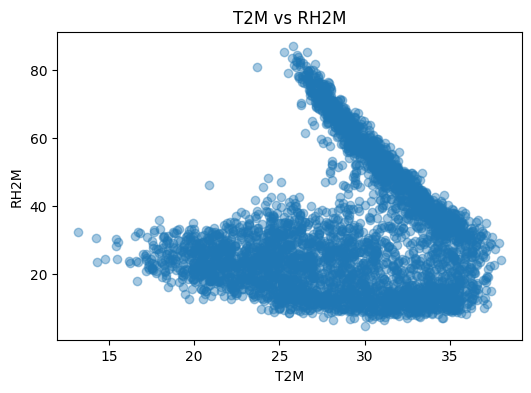

In [21]:
plt.figure(figsize=(6, 4))
plt.scatter(df["T2M"], df["RH2M"], alpha=0.4)
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.title("T2M vs RH2M")
plt.show()

In [22]:
corr_matrix = num_df.corr(numeric_only=True)
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
top_corr = upper_triangle.stack().sort_values(key=np.abs, ascending=False).head(3)

print("Top 3 strongest correlations (absolute value):")
for (var_a, var_b), corr_val in top_corr.items():
    direction = "positive" if corr_val > 0 else "negative"
    print(f"{var_a} vs {var_b}: {corr_val:.3f} ({direction})")

Top 3 strongest correlations (absolute value):
DOY vs Month: 0.997 (positive)
T2M vs T2M_MIN: 0.942 (positive)
RH2M vs QV2M: 0.935 (positive)


## Distribution analysis
Rainfall is concentrated at lower values with a long right tail, which means a small number of heavier rain events account for much of the spread.
The log view reduces that tail and makes the common low-to-moderate rainfall range easier to inspect.
The bubble chart shows rainfall size on the scatter, so wetter and more humid points stand out more clearly.

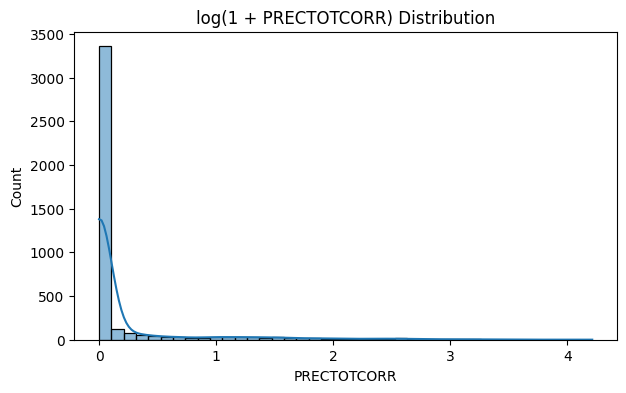

In [23]:
plt.figure(figsize=(7, 4))
sns.histplot(np.log1p(df["PRECTOTCORR"].dropna()), bins=40, kde=True)
plt.title("log(1 + PRECTOTCORR) Distribution")
plt.show()

### Distribution interpretation
Rainfall is strongly right-skewed, so most observations sit near zero while a smaller number of high-rain days stretch the distribution to the right.
Applying log(1 + PRECTOTCORR) compresses the large values and makes the low-rainfall structure easier to read.
In the bubble chart, the bigger bubbles mostly appear in the wetter, higher-humidity part of the scatter and generally align with slightly lower temperatures.